In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle


In [2]:
def select_by_lonlat(ds, lon_target, lat_target):
    lat = ds['gphit'].values
    lon = ds['glamt'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return (y_idx, x_idx)


In [3]:
# Open model and config files

catalog = OceanDataCatalog(catalog_name='noc-model-stac')
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1_annual = catalog.open_dataset(id=catalog.Items[0].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
ds1_monthly = catalog.open_dataset(id=catalog.Items[1].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[0].id)

# Merge into a data tree
datasets_annual = {'parent': {'domain': config, 'gridT': ds1_annual}}
dt_global_annual = NEMODataTree.from_datasets(datasets = datasets_annual)
datasets_monthly = {'parent': {'domain': config, 'gridT': ds1_monthly}}
dt_global_monthly = NEMODataTree.from_datasets(datasets = datasets_monthly)

# Clip to North Atlantic 
bbox = (-85.0, 0.0, 0.0, 80.0)
dt_annual = dt_global_annual.clip_grid(grid='/gridT', bbox=bbox)
dt_monthly = dt_global_monthly.clip_grid(grid='/gridT', bbox=bbox)

# Convert to datasets
ds_annual = (dt_annual['/gridT']).dataset
ds_monthly = (dt_monthly['/gridT']).dataset


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [37]:
septembers = []
for year in range (1990, 2025):
    septembers.append(f'{year}-09-15')

marches = []
for year in range (1990, 2025):
    marches.append(f'{year}-03-15')

september_data = ds_monthly['tos_con'].sel(time_counter=septembers, method='nearest')
september_data['time_counter'] = september_data['time_counter'].dt.year
march_data = ds_monthly['tos_con'].sel(time_counter=marches, method = 'nearest')
march_data['time_counter'] = march_data['time_counter'].dt.year

amplitude = (september_data - march_data).compute()


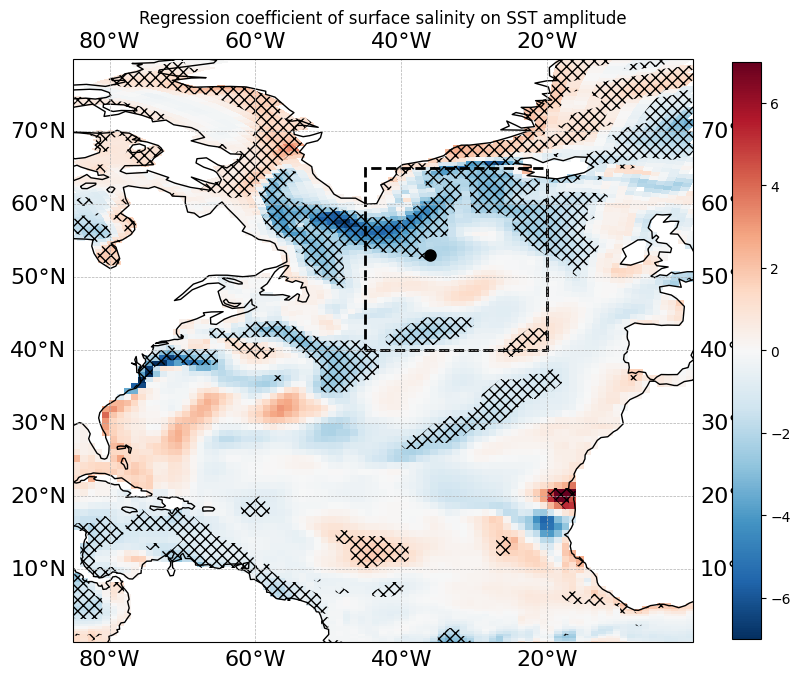

In [42]:
## Surface

salinity_0 = (ds_annual['so_abs'].sel(deptht = 0, method = 'nearest')).compute()
salinity_0['time_counter'] = salinity_0['time_counter'].dt.year

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_0.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        results = linregress(sal_ts, amp_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='slope',
        attrs={'description': 'Regression slope of salinity on amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for regression of salinity on amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -7, vmax = 7)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Regression coefficient of surface salinity on SST amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

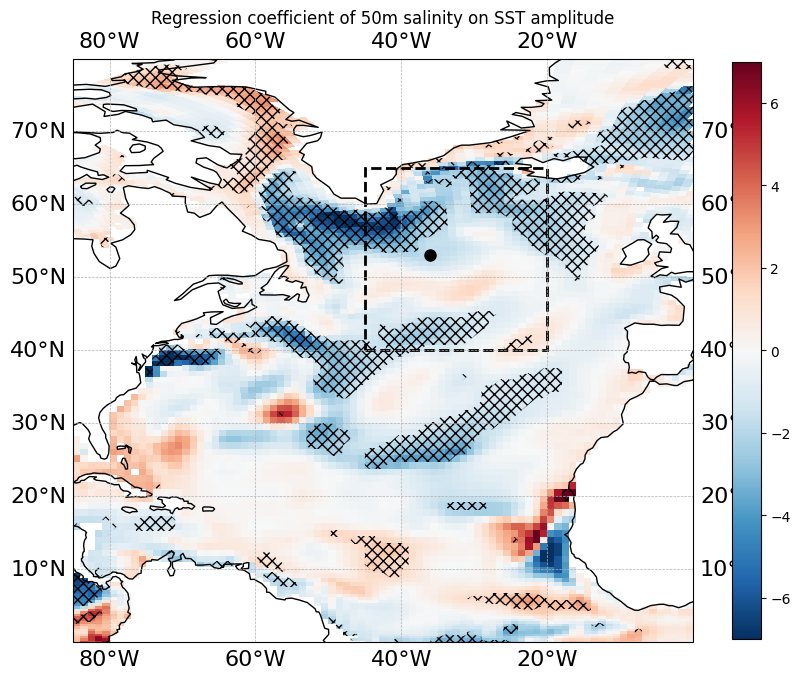

In [41]:
## 50m (actually 47)

salinity_50 = (ds_annual['so_abs'].sel(deptht = 50, method = 'nearest')).compute()
salinity_50['time_counter'] = salinity_50['time_counter'].dt.year

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

print('starting loop')
for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_50.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        results = linregress(sal_ts, amp_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='slope',
        attrs={'description': 'Regression slope of salinity on amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for regression of salinity on amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -7, vmax = 7)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Regression coefficient of 50m salinity on SST amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

starting loop


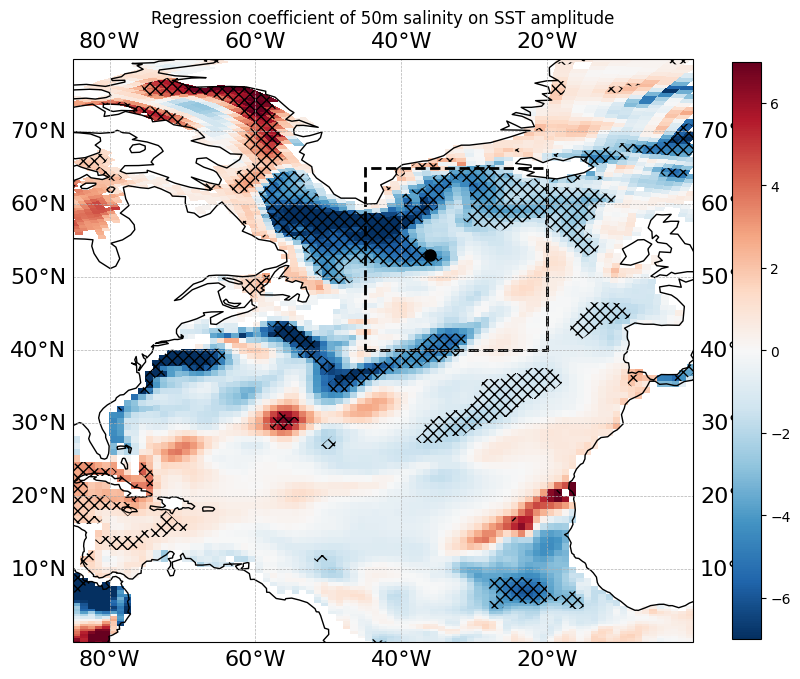

In [43]:
## 100m 

salinity_100 = (ds_annual['so_abs'].sel(deptht = 100, method = 'nearest')).compute()
salinity_100['time_counter'] = salinity_100['time_counter'].dt.year

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

print('starting loop')
for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_100.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        results = linregress(sal_ts, amp_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='slope',
        attrs={'description': 'Regression slope of salinity on amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for regression of salinity on amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -7, vmax = 7)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Regression coefficient of 50m salinity on SST amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

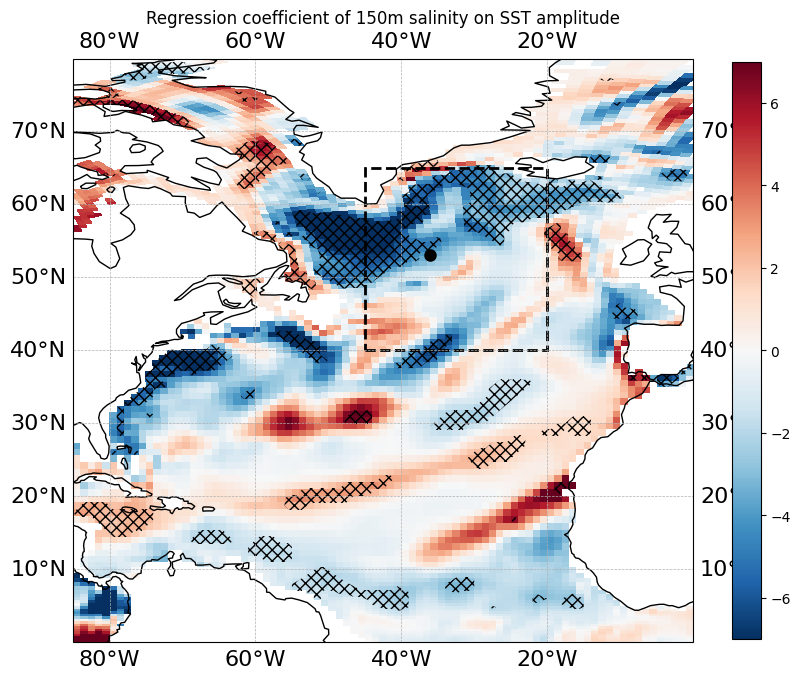

In [44]:
## 150m

salinity_150 = (ds_annual['so_abs'].sel(deptht = 150, method = 'nearest')).compute()
salinity_150['time_counter'] = salinity_150['time_counter'].dt.year

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_150.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        results = linregress(sal_ts, amp_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='slope',
        attrs={'description': 'Regression slope of salinity on amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for regression of salinity on amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -7, vmax = 7)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Regression coefficient of 150m salinity on SST amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

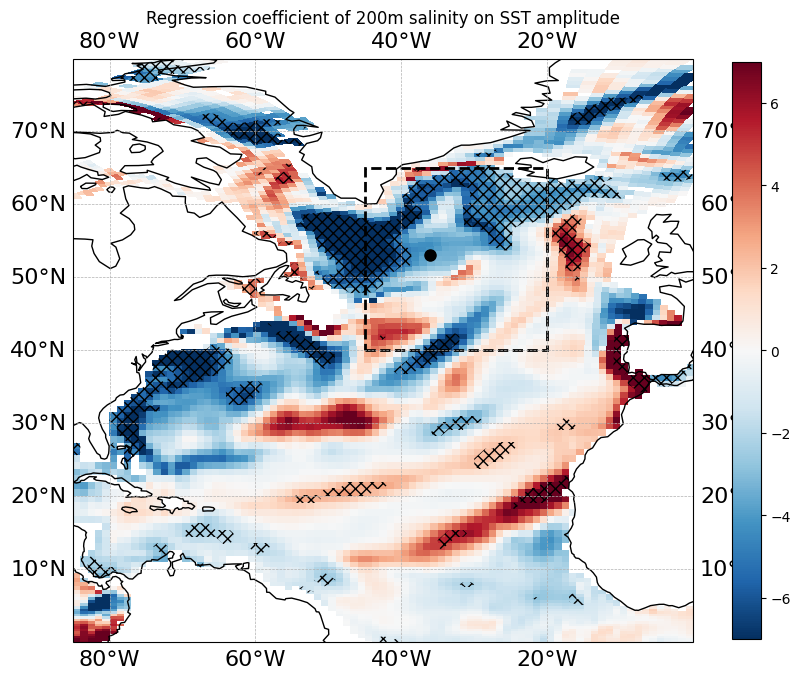

In [45]:
## 200m

salinity_200 = (ds_annual['so_abs'].sel(deptht = 200, method = 'nearest')).compute()
salinity_200['time_counter'] = salinity_200['time_counter'].dt.year

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_200.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        results = linregress(sal_ts, amp_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='slope',
        attrs={'description': 'Regression slope of salinity on amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for regression of salinity on amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -7, vmax = 7)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Regression coefficient of 200m salinity on SST amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

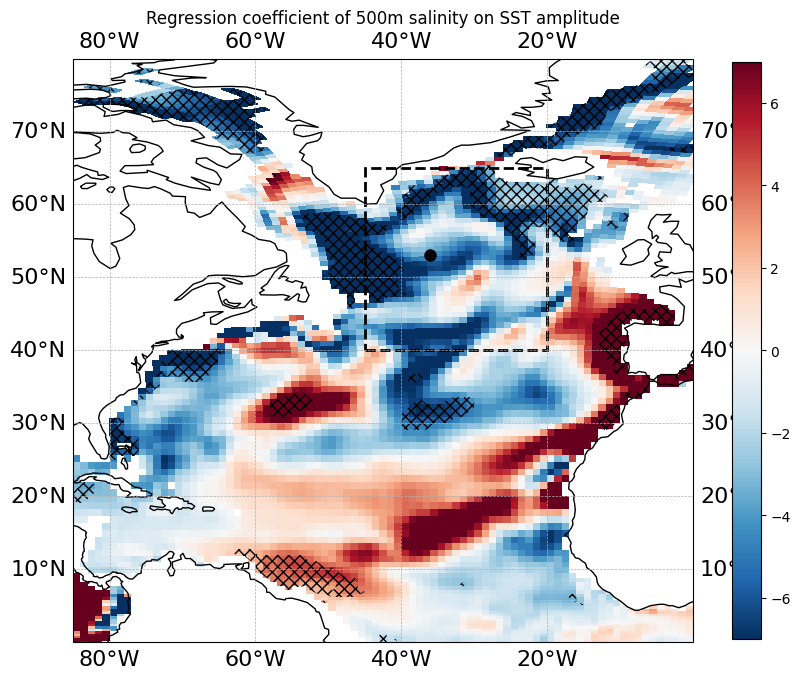

In [46]:
## 500m

salinity_500 = (ds_annual['so_abs'].sel(deptht = 500, method = 'nearest')).compute()
salinity_500['time_counter'] = salinity_500['time_counter'].dt.year

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_500.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        results = linregress(sal_ts, amp_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='slope',
        attrs={'description': 'Regression slope of salinity on amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for regression of salinity on amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -7, vmax = 7)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Regression coefficient of 500m salinity on SST amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

In [ ]:
## 1 km

salinity_1000 = (ds_annual['so_abs'].sel(deptht = 1000, method = 'nearest')).compute()
salinity_1000['time_counter'] = salinity_1000['time_counter'].dt.year

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_1000.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        results = linregress(sal_ts, amp_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='slope',
        attrs={'description': 'Regression slope of salinity on amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for regression of salinity on amplitude'})

sig_mask = pval_da < 0.05

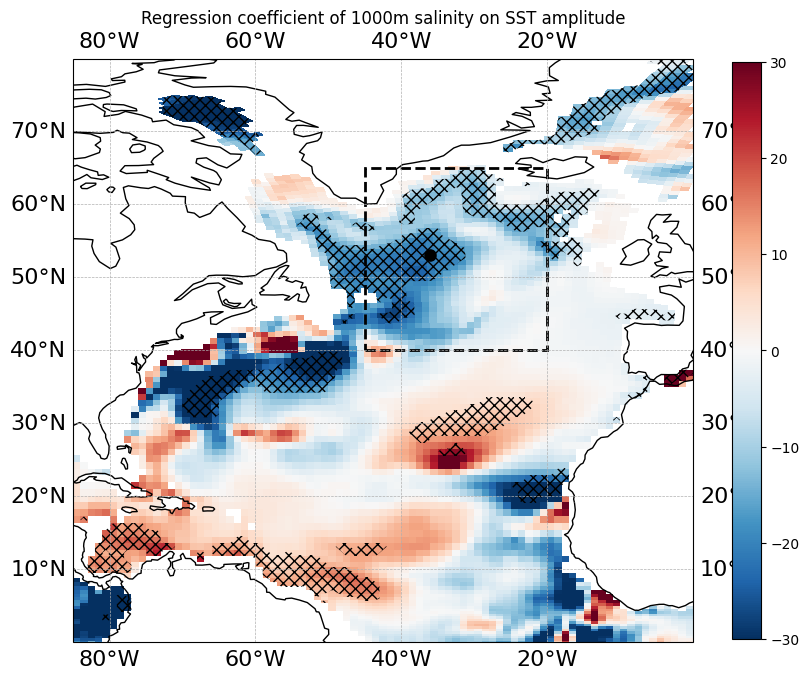

In [51]:


fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -30, vmax = 30)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Regression coefficient of 1000m salinity on SST amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

In [52]:
## 2 km

salinity_2000 = (ds_annual['so_abs'].sel(deptht = 2000, method = 'nearest')).compute()
salinity_2000['time_counter'] = salinity_2000['time_counter'].dt.year

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx).values
        sal_ts = salinity_2000.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        results = linregress(sal_ts, amp_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='slope',
        attrs={'description': 'Regression slope of salinity on amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for regression of salinity on amplitude'})

sig_mask = pval_da < 0.05

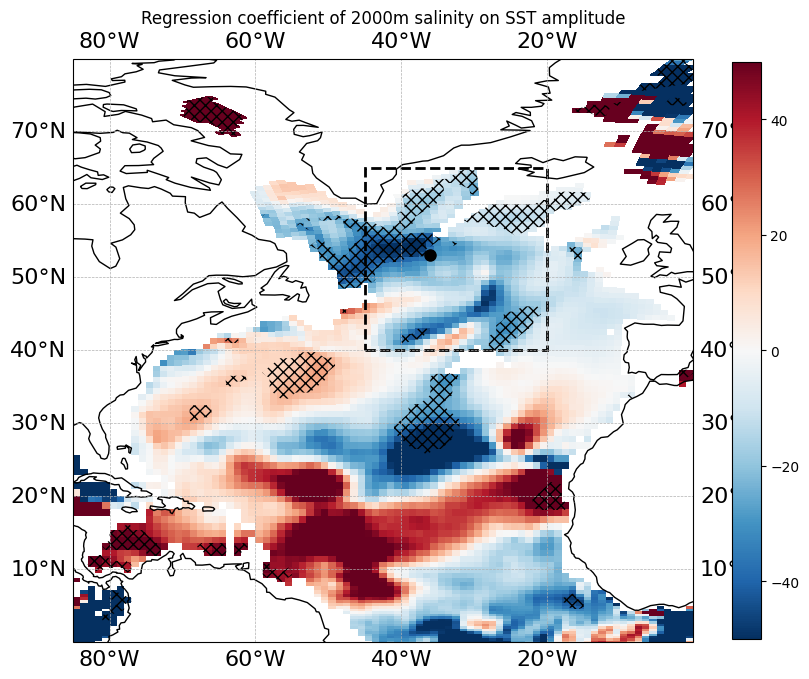

In [54]:


fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -50, vmax = 50)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Regression coefficient of 2000m salinity on SST amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

starting loop


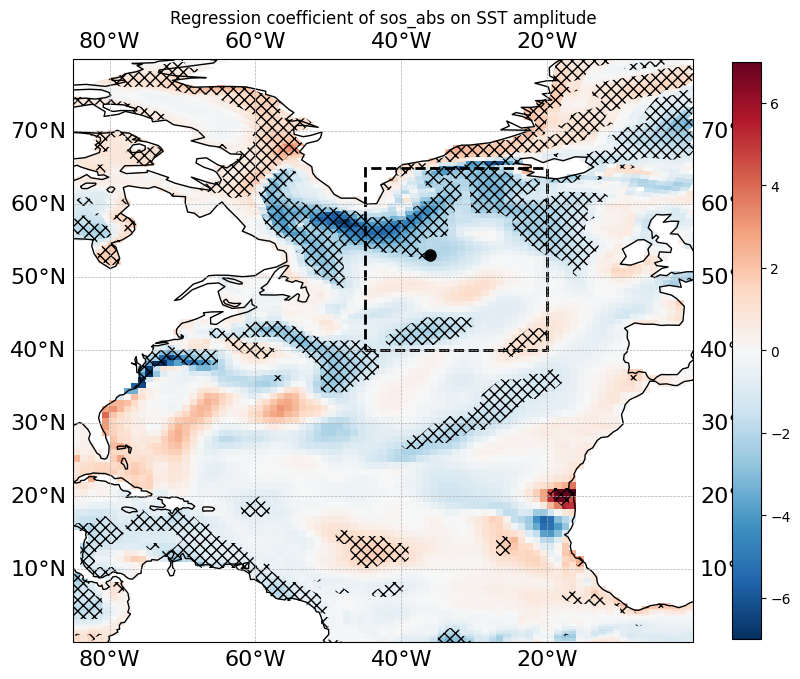

In [55]:
## Using sos_abs - should be same as 0m from so_abs

sos_abs = (ds_annual['sos_abs']).compute()
sos_abs['time_counter'] = sos_abs['time_counter'].dt.year

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

print('starting loop')
for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx).values
        sal_ts = sos_abs.isel(j=y_idx, i=x_idx).values
        if np.isnan(amp_ts).all():
            continue
        results = linregress(sal_ts, amp_ts) 
        r_data[y_idx, x_idx] = results.slope
        p_data[y_idx, x_idx] = results.pvalue


r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='slope',
        attrs={'description': 'Regression slope of salinity on amplitude'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'p-value for regression of salinity on amplitude'})

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -7, vmax = 7)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Regression coefficient of sos_abs on SST amplitude')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)